# LBL TCP 3 Datset


Import libraries


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from custom_lstm.utils import ew_acf

In [4]:
INPUT_FILE = "../../data/raw/lbl-tcp-3.tcp"
OUTPUT_FILE = "../../data/preprocessed/lbl_tcp_3.csv"

In [5]:
df = pd.read_csv(INPUT_FILE, sep=" ", names=["Timestamp", "Src Host", "Dst Host", "Src Port", "Dst Port", "Bytes"])
df.head()

,Timestamp,Src Host,Dst Host,Src Port,Dst Port,Bytes
0,7.591038e+08,1,2,23,2436,1
1,1.044500e-02,2,1,2436,23,2
2,2.377500e-02,1,2,23,2436,2
3,2.655800e-02,2,1,2436,23,1
4,2.900200e-02,3,4,3930,119,42


In [6]:
def parse_lbl_tcp(data, bin_size="1s"):
    """
    Parses LBL-TCP-3 sanitized format and bins it into a time series.
    Handles the 'Absolute First / Relative Subsequent' timestamp format.
    """

    timestamps = df["Timestamp"].values.copy()  # Use .copy() to avoid SettingWithCopy warnings

    if timestamps[0] > 1e8:
        timestamps[0] = 0.0

    if len(timestamps) > 1 and timestamps[1] > 1e8:
        timestamps = timestamps - timestamps[0]

    df["seconds_offset"] = timestamps

    # 3. Create a DateTime Index for Binning
    # We use an arbitrary start date since we only care about the *shape* of the series
    start_date = pd.Timestamp("1994-01-20")
    data["datetime"] = start_date + pd.to_timedelta(data["seconds_offset"], unit="s")

    # 4. Binning (Resampling)
    # Sum the 'bytes' column for every bin_size
    print(f"Binning data into {bin_size} intervals...")
    time_series = data.set_index("datetime")["Bytes"].resample(bin_size).sum().fillna(0)
    time_series.name = "time_series"
    return time_series

In [7]:
time_series = parse_lbl_tcp(df, bin_size="1s")
time_series.to_csv(OUTPUT_FILE, index=False)
time_series.head()

Binning data into 1s intervals...


datetime
1994-01-20 00:00:00     5497
1994-01-20 00:00:01    11146
1994-01-20 00:00:02    13986
1994-01-20 00:00:03    10541
1994-01-20 00:00:04     6781
Freq: s, Name: time_series, dtype: int64

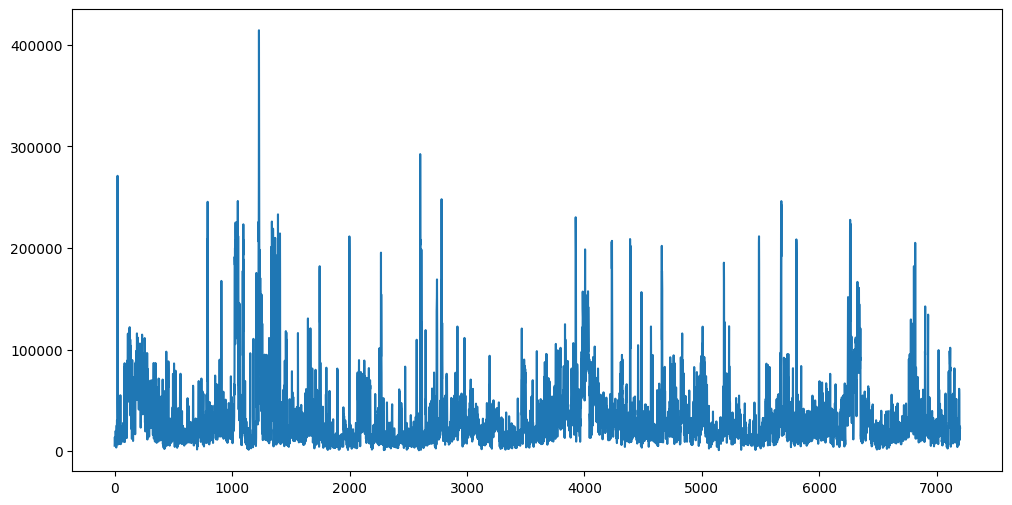

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(time_series.to_numpy()[:], label="Time Series")

## ACF


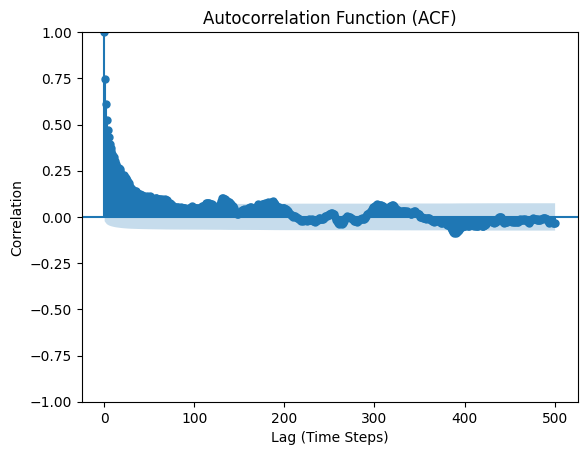

In [9]:
plot_acf(time_series, lags=500, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF

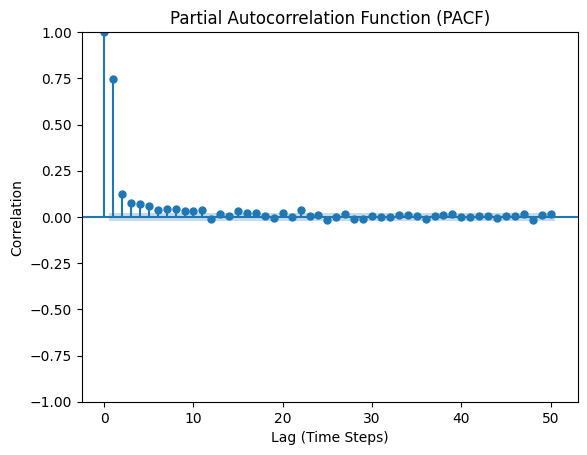

In [10]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### EW-ACF

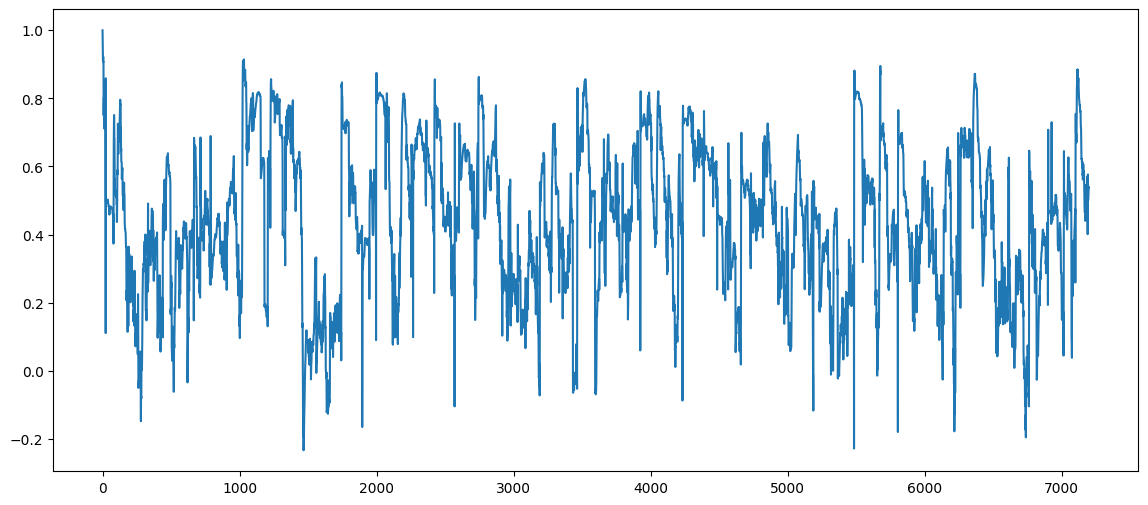

In [13]:
autocorr = ew_acf(time_series, lag=1, lambda_=0.95)
plt.figure(figsize=(14, 6))
plt.plot(autocorr)

## Hurst Exponent


Hurst Exponent (H): 0.8063


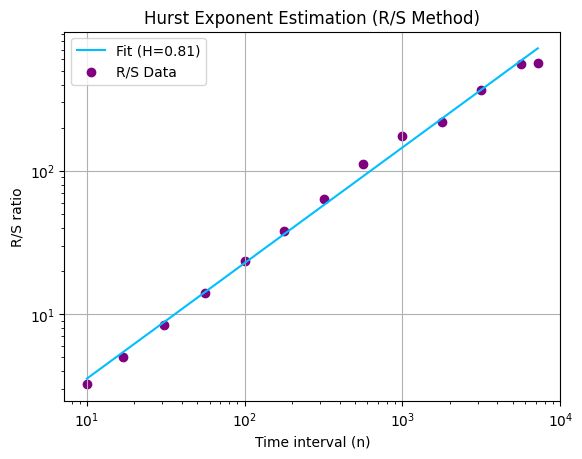

In [30]:
H, c, data = compute_Hc(time_series, kind="change", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()